# Handling Talsim 5 databases with the `talsim` package

## Imports and setup

In [1]:
import datetime as dt
import logging
from pathlib import Path
import sys

import pandas as pd

# import the talsim package and the Timeseries class
# if necessary adjust `basedir` to point to the directory containing the `lib` directory
basedir = Path().absolute().parent
sys.path.append(str(basedir))

import talsimpy as talsim
from talsimpy import Timeseries

In [2]:
# setup logging to see log messages in the notebook
# create a console handler
ch = logging.StreamHandler()
ch.setLevel(logging.INFO)
# add formatters to the handler
ch.setFormatter(logging.Formatter('%(name)-12s %(levelname)-8s %(message)s'))
# config
logging.basicConfig(
    level=logging.NOTSET,
    handlers=[ch],
    force=True
)

## Opening a database

In [3]:
tdb = talsim.TalsimDatabase(r"data/talsim_db/Demo.db")

print("Database contains the following scenarios:")
for id, name in tdb.scenarios.items():
    print(f"{id}: {name}")

Database contains the following scenarios:
1: Getting started


### Opening a scenario

In [4]:
tds = tdb.open_scenario(1)
print(tds)

TalsimScenario 'Getting started' with ScenarioId 1 in data\talsim_db\Demo.db


In [5]:
# get all simulations defined in the db
print(tds.simulations)

{1: 'Sim1'}


In [6]:
# check the active simulation Id
print(tds.active_simulation)

1


In [7]:
# set the active simulation id
tds.set_active_simulation(1)

In [8]:
# check the simulation start and end dates
print(tds.sim_start, tds.sim_end)

2004-08-01 00:00:00 2021-11-01 00:00:00


## Manipulating a scenario

In [9]:
# make a copy of the database in a subfolder "tmp" to avoid modifying the original database
path_tmp = tds.path / "tmp"
path_tmp.mkdir(exist_ok=True)

tds = tds.copy(path_tmp)
tds

TalsimScenario 'Getting started' with ScenarioId 1 in data\talsim_db\tmp\Demo.db

In [10]:
# change the active simulation id
tds.set_active_simulation(1)

In [11]:
# change sim start and end dates of active simulation using dedicated methods
tds.set_sim_start(dt.datetime(2005, 7, 1))
tds.set_sim_end(dt.datetime(2005, 12, 31))

In [12]:
# check the changed simulation start and end dates
print(tds.sim_start, tds.sim_end)

2005-07-01 00:00:00 2005-12-31 00:00:00


In [13]:
# change some more values in the database using the generic method
tds.set_parameter(table="Simulation", id=1, field="StartKey", value="T001")

## Simulating

In [ ]:
# instantiate an engine
path_engine = r"<path_to_talsim_engine>"
engine = talsim.TalsimEngine(f"{path_engine}")
engine

TalsimEngine in C:\data\Projekte\4.1.27

In [17]:
# check the engine version
engine.version

'4.1.27'

In [18]:
# simulate the active simulation
engine.simulate(tds, name="demo", path_timeseries=r"data/talsim_db/Demo_zre", path_output=path_tmp)

talsimpy.talsimengine INFO     No simulation id provided, using active simulation id 1 from scenario.
talsimpy.talsimengine INFO     Launching Talsim-NG v4.1.27...
talsimpy.talsimengine WARNING  Simulation produced warnings! See Talsim warning file: data\talsim_db\tmp\demo.wrn
talsimpy.talsimengine INFO     Simulation successful!


True

In [ ]:
# or alternatively, launch a simulation using an existing run file (no TalsimScenario instance required):
runfile_path = r"data/talsim_db/demo.run"
engine.launch(runfile_path)

## Checking simulation results

In [20]:
# check the warnings (works similarly for errors)
print(tds.warnings)

None


In [21]:
# check for timeseries result files
tds.timeseries_result_files

[WindowsPath('data/talsim_db/tmp/demo.KTR.WEL'),
 WindowsPath('data/talsim_db/tmp/demo.WEL')]

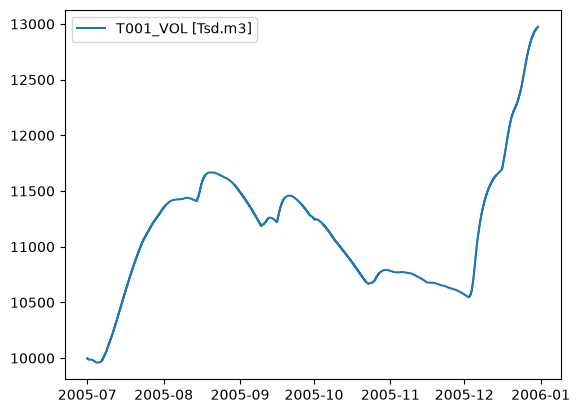

In [22]:
# read and plot a result
file_wel = tds.timeseries_result_files[1]
ts, = Timeseries.read_wel(file_wel, ["T001_VOL"])
ts.plot()